In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [3]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [4]:
print(list(Path("data").glob("*.csv")))

[PosixPath('data/DZA_selected.csv'), PosixPath('data/IND_SL.TLF.CACT.MA.ZS.csv'), PosixPath('data/MAR_raw.csv'), PosixPath('data/IND_SL.TLF.CACT.FE.ZS.csv'), PosixPath('data/KWT_raw.csv'), PosixPath('data/IND_SP.DYN.CONU.ZS.csv'), PosixPath('data/OMN_selected.csv'), PosixPath('data/QAT_raw.csv'), PosixPath('data/MAR_selected.csv'), PosixPath('data/IND_SP.DYN.CONM.ZS.csv'), PosixPath('data/all_countries_selected.csv'), PosixPath('data/IND_SH.STA.MMRT.csv'), PosixPath('data/IND_SG.IND.WORK.EQ.csv'), PosixPath('data/IND_SE.ADT.1524.LT.FE.ZS.csv'), PosixPath('data/BHR_raw.csv'), PosixPath('data/IND_SE.ADT.1524.LT.MA.ZS.csv'), PosixPath('data/KWT_selected.csv'), PosixPath('data/IND_SG.CNT.SIGN.EQ.csv'), PosixPath('data/all_countries_combined.csv'), PosixPath('data/LBY_selected.csv'), PosixPath('data/IRQ_selected.csv'), PosixPath('data/IND_SE.ENR.SECO.FM.ZS.csv'), PosixPath('data/IND_SG.HLD.HEAD.EQ.csv'), PosixPath('data/IND_SG.REM.RIGT.EQ.csv'), PosixPath('data/BHR_selected.csv'), PosixPath

In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/all_countries_selected.csv")
meta = pd.read_csv("data/indicator_metadata_with_units.csv")

In [6]:
df.head()  

,year,value,country_id,country_name,indicator_id,indicator_name,unit_type
0,2024,NaN,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
1,2023,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
2,2022,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
3,2021,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
4,2020,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)


In [7]:
df.rename(columns={'unit_type':'Unit_Type','year':"Year","value":"Value",
                   "country_name":"Country",'indicator_id':"Indicator Code",
                   "country_id":"Country Code","indicator_name":"Indicator Name"}, inplace=True)

In [14]:
df.rename(columns = {"Unit_Type":"Unit Type"}, inplace=True)

In [15]:
df.head()

,Year,Value,Country Code,Country,Indicator Code,Indicator Name,Unit Type
0,2024,NaN,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
1,2023,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
2,2022,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
3,2021,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
4,2020,1.0,BH,Bahrain,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)


In [16]:
columns_order = ['Country','Country Code', 'Year', 'Indicator Code', 'Indicator Name', 'Value', "Unit Type"]
df = df[columns_order]

In [17]:
df['Unit Type'].unique()

array(['Binary (1/0)', 'Index / Score', 'Rate per 100,000', 'Percent (%)',
       'Rate per 1,000', 'Currency (US$)', 'Years'], dtype=object)

In [18]:
df.shape

(14625, 7)

In [19]:
df.duplicated().sum()

0

In [21]:
df.isna().sum()

Country              0
Country Code         0
Year                 0
Indicator Code       0
Indicator Name       0
Value             3621
Unit Type            0
dtype: int64

In [22]:
empty_indicators = (
    df.groupby("Indicator Code")["Value"]
    .apply(lambda x: x.isna().all())
)

# Filter only True (completely missing indicators)
empty_indicators = empty_indicators[empty_indicators].index.tolist()

print(f"Indicators with no data: {len(empty_indicators)}")
print(empty_indicators[:10]) 

Indicators with no data: 0
[]


In [23]:
df["Value"].isna().sum(), df["Value"].isna().mean()

(3621, 0.2475897435897436)

In [24]:
df.groupby("Indicator Name")["Value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(20)


Indicator Name
Women who were first married by age 18 (% of women ages 20-24)                                         305
Women who were first married by age 15 (% of women ages 20-24)                                         305
Contraceptive prevalence, any modern method (% of married women ages 15-49)                            283
Contraceptive prevalence, any method (% of married women ages 15-49)                                   281
Literacy rate, adult male (% of males ages 15 and above)                                               245
Literacy rate, adult total (% of people ages 15 and above)                                             245
Literacy rate, youth male (% of males ages 15-24)                                                      244
Literacy rate, adult female (% of females ages 15 and above)                                           242
Literacy rate, youth female (% of females ages 15-24)                                                  236
Educational attainment

In [25]:
df.groupby("Country")["Value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(10)


Country
Libya           347
Yemen, Rep.     333
Iraq            296
Algeria         292
Bahrain         291
Morocco         280
Qatar           271
Saudi Arabia    270
Oman            262
Kuwait          259
Name: Value, dtype: int64

<Axes: title={'center': 'Missing Values by Year'}, xlabel='Year'>

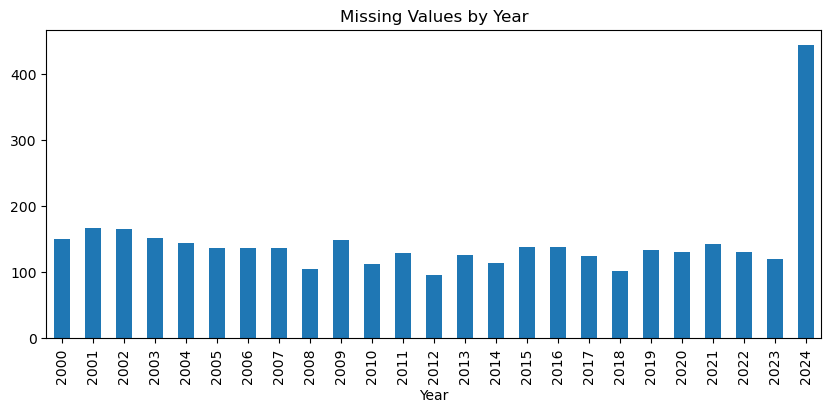

In [34]:
df.groupby("Year")["Value"].apply(lambda x: x.isna().sum()).plot(kind="bar", figsize=(10,4), title="Missing Values by Year")


In [39]:
df.groupby("Year")["Value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head()


Year
2024    444
2001    167
2002    166
2003    152
2000    150
Name: Value, dtype: int64

In [40]:
df = df[df["Year"] != 2024].copy()

In [41]:
df["Year"].unique()
df["Year"].max()


2023

In [42]:
print(df.shape)


(14040, 6)


In [43]:
df["Value"].isna().sum(), df["Value"].isna().mean()


(3177, 0.22628205128205128)

In [51]:
inds = ["SP.M18.2024.FE.ZS", "SP.M15.2024.FE.ZS","SP.DYN.CONM.ZS", "SP.DYN.CONU.ZS"]

subset = df[df["Indicator Code"].isin(inds)]

missing_by_country = (
    subset.groupby(["Indicator Code", "Country"])["Value"]
    .apply(lambda x: x.isna().sum())
    .reset_index(name="missing_count")
)
missing_by_country.sort_values(["Indicator Code", "missing_count"], ascending=[True, False]).head(20)


,Indicator Code,Country,missing_count
1,SP.DYN.CONM.ZS,Bahrain,24
5,SP.DYN.CONM.ZS,Kuwait,24
9,SP.DYN.CONM.ZS,Qatar,23
6,SP.DYN.CONM.ZS,Libya,21
7,SP.DYN.CONM.ZS,Morocco,21
8,SP.DYN.CONM.ZS,Oman,21
10,SP.DYN.CONM.ZS,Saudi Arabia,21
12,SP.DYN.CONM.ZS,"Yemen, Rep.",21
3,SP.DYN.CONM.ZS,Iraq,20
0,SP.DYN.CONM.ZS,Algeria,19


In [52]:
missing_by_country["total_rows"] = (
    subset.groupby(["Indicator Code", "Country"])["Value"].transform("count")
)
missing_by_country["missing_rate"] = (
    missing_by_country["missing_count"] / missing_by_country["total_rows"]
)

missing_by_country.sort_values(["Indicator Code", "missing_rate"], ascending=[True, False]).head(10)


,Indicator Code,Country,missing_count,total_rows,missing_rate
0,SP.DYN.CONM.ZS,Algeria,19,NaN,NaN
1,SP.DYN.CONM.ZS,Bahrain,24,NaN,NaN
2,SP.DYN.CONM.ZS,"Egypt, Arab Rep.",19,NaN,NaN
3,SP.DYN.CONM.ZS,Iraq,20,NaN,NaN
4,SP.DYN.CONM.ZS,Jordan,18,NaN,NaN
5,SP.DYN.CONM.ZS,Kuwait,24,NaN,NaN
6,SP.DYN.CONM.ZS,Libya,21,NaN,NaN
7,SP.DYN.CONM.ZS,Morocco,21,NaN,NaN
8,SP.DYN.CONM.ZS,Oman,21,NaN,NaN
9,SP.DYN.CONM.ZS,Qatar,23,NaN,NaN


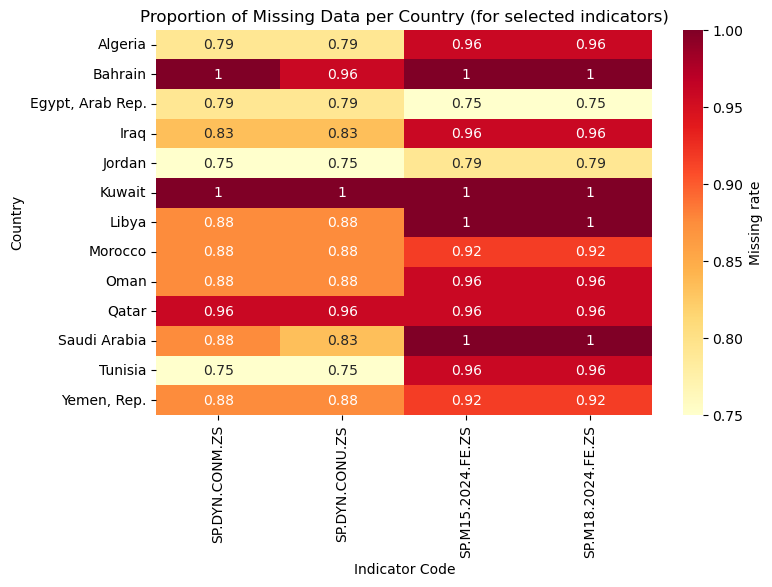

In [53]:
pivot = subset.pivot_table(
    values="Value",
    index="Country",
    columns="Indicator Code",
    aggfunc=lambda x: x.isna().mean()
)
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="YlOrRd", cbar_kws={'label': 'Missing rate'})
plt.title("Proportion of Missing Data per Country (for selected indicators)")
plt.show()


In [54]:
df = df[~df["Indicator Code"].isin(inds)].copy()


In [58]:
df.isna().sum()

Country              0
Year                 0
Indicator Code       0
Indicator Name       0
Value             2055
Unit_Type            0
dtype: int64

In [59]:
(
    df[df["Value"].isna()]
    .groupby("Country")["Value"]
    .count()
    .sort_values(ascending=False)
)


Country
Algeria             0
Bahrain             0
Egypt, Arab Rep.    0
Iraq                0
Jordan              0
Kuwait              0
Libya               0
Morocco             0
Oman                0
Qatar               0
Saudi Arabia        0
Tunisia             0
Yemen, Rep.         0
Name: Value, dtype: int64

In [60]:
df[df["Value"].isna()].groupby("Indicator Code")["Value"].count().sort_values(ascending=False).head(10)
df[df["Value"].isna()].groupby("Year")["Value"].count().sort_values(ascending=False)


Year
2000    0
2001    0
2022    0
2021    0
2020    0
2019    0
2018    0
2017    0
2016    0
2015    0
2014    0
2013    0
2012    0
2011    0
2010    0
2009    0
2008    0
2007    0
2006    0
2005    0
2004    0
2003    0
2002    0
2023    0
Name: Value, dtype: int64

In [67]:
df["Value"].isna().sum(), round(df["Value"].isna().mean() * 100, 2)


(2055, 16.06)

In [70]:
(
    df[df["Value"].isna()]
    .groupby(["Indicator Name"])["Value"]
    .size()
    .sort_values(ascending=False)
    .head(10)
)


Indicator Name
Literacy rate, adult male (% of males ages 15 and above)                                               234
Literacy rate, adult total (% of people ages 15 and above)                                             234
Literacy rate, youth male (% of males ages 15-24)                                                      233
Literacy rate, adult female (% of females ages 15 and above)                                           231
Literacy rate, youth female (% of females ages 15-24)                                                  225
Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)      217
Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)    216
Proportion of women in ministerial level positions (%)                                                 162
School enrollment, secondary (gross), gender parity index (GPI)                                        150
Inflation, consumer pr

In [72]:
df[df["Value"].isna()].groupby(["Country"])["Value"].size().sort_values(ascending=False).head(10)

Country
Libya           222
Yemen, Rep.     210
Iraq            175
Algeria         173
Bahrain         168
Morocco         159
Saudi Arabia    153
Qatar           144
Oman            139
Jordan          136
Name: Value, dtype: int64

In [71]:
df[df["Value"].isna()].groupby(["Year"])["Value"].size().sort_values(ascending=False)


Year
2002    120
2001    117
2000    111
2003    108
2009    100
2004     96
2021     93
2006     92
2007     91
2016     88
2005     88
2019     87
2015     86
2011     81
2013     80
2020     79
2022     79
2023     76
2017     72
2014     72
2018     66
2010     60
2008     59
2012     54
Name: Value, dtype: int64

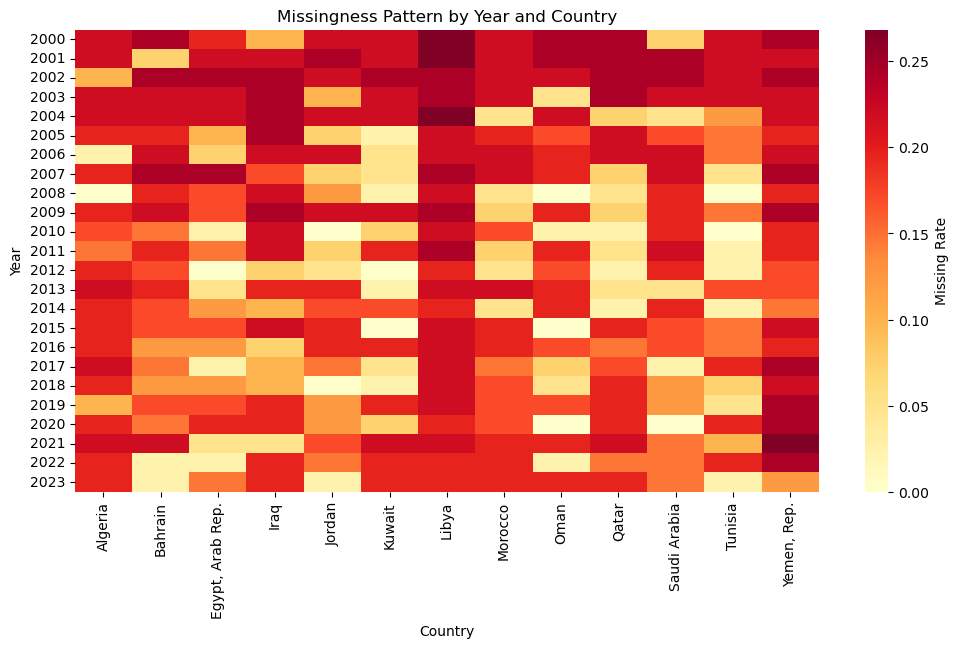

In [73]:
pivot = (
    df.pivot_table(values="Value", index="Year", columns="Country", aggfunc=lambda x: x.isna().mean())
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={'label': 'Missing Rate'})
plt.title("Missingness Pattern by Year and Country")
plt.show()


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_10648/3502222808.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_by_indicator.head(15), y="Indicator Code", x="Missing (%)", palette="mako")


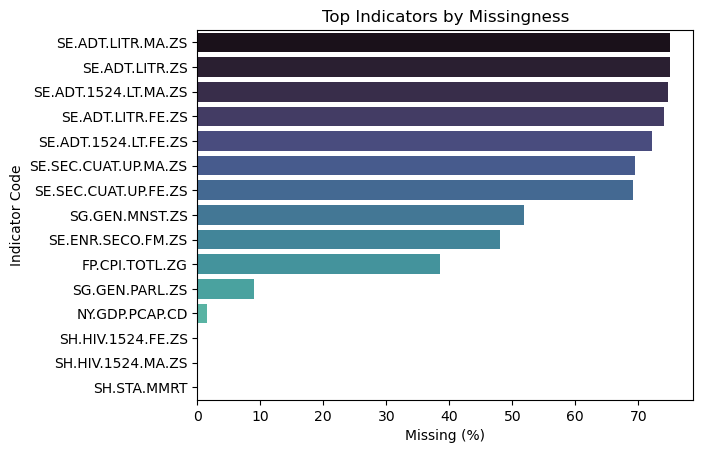

In [74]:
missing_by_indicator = (
    df.groupby("Indicator Code")["Value"]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index(name="Missing (%)")
    .sort_values("Missing (%)", ascending=False)
)
sns.barplot(data=missing_by_indicator.head(15), y="Indicator Code", x="Missing (%)", palette="mako")
plt.title("Top Indicators by Missingness")
plt.show()


Horizontal streaks (same country missing many years) → use forward/backward fill.

Random holes → interpolation.

Isolated countries/indicators → leave null or regional average.

In [75]:
null_summary = (
    df.groupby("Indicator Code")["Value"]
    .agg([("missing_count", lambda x: x.isna().sum()),
          ("missing_rate", lambda x: x.isna().mean()),
          ("years_tracked", "count")])
    .reset_index()
    .sort_values("missing_rate", ascending=False)
)
null_summary.head(10)


,Indicator Code,missing_count,missing_rate,years_tracked
5,SE.ADT.LITR.MA.ZS,234,0.750000,78
6,SE.ADT.LITR.ZS,234,0.750000,78
3,SE.ADT.1524.LT.MA.ZS,233,0.746795,79
4,SE.ADT.LITR.FE.ZS,231,0.740385,81
2,SE.ADT.1524.LT.FE.ZS,225,0.721154,87
9,SE.SEC.CUAT.UP.MA.ZS,217,0.695513,95
8,SE.SEC.CUAT.UP.FE.ZS,216,0.692308,96
15,SG.GEN.MNST.ZS,162,0.519231,150
7,SE.ENR.SECO.FM.ZS,150,0.480769,162
0,FP.CPI.TOTL.ZG,120,0.384615,192


# Framework for Dealing with Null Values

### Prep

In [77]:
df = df.sort_values(by=["Country", "Indicator Code", "Year"]).reset_index(drop=True)

### Drop Unreliable Years

In [78]:
df = df[df["Year"] != 2024].copy()


In [79]:
to_drop = ["SE.ADT.LITR.MA.ZS","SE.ADT.LITR.ZS","SE.ADT.1524.LT.MA.ZS",
    "SE.ADT.LITR.FE.ZS","SE.ADT.1524.LT.FE.ZS"]
df = df[~df["Indicator Code"].isin(to_drop)].copy()

In [80]:
df.isna().sum()

Country             0
Year                0
Indicator Code      0
Indicator Name      0
Value             898
Unit_Type           0
dtype: int64

In [82]:
def classify_series(s:pd.Series) -> dict:
    """
    s is the Value series for a single (Indicator Code, Country Code),
    indexed by Year (sorted).
    """
    
    #Basic stats
    n= len(s)
    miss_rate = s.isna().mean()
    valid = s.notna().sum()
    res = {'missing_rate':miss_rate, "n":n, "valid":valid}
    
    if valid ==0:
        res["pattern"] = "all_missing"
        res["method"] = "drop_group"
        return res
    
    first_valid_pos = s.first_valid_index()
    last_valid_pos = s.last_valid_index()
    
     # Booleans for edge/internal gaps
    leading_gap  = s.loc[:first_valid_pos].iloc[:-1].isna().any() if first_valid_pos is not None else False
    trailing_gap = s.loc[last_valid_pos:].iloc[1:].isna().any()   if last_valid_pos  is not None else False
    
    internal_gap = False
    if first_valid_pos is not None and last_valid_pos is not None and first_valid_pos != last_valid_pos:
        internal_gap = s.loc[first_valid_pos:last_valid_pos].isna().any()
        
    if miss_rate >=0.90:
        res["pattern"] = "predominantly_missing"
        res["method"] = "leave_null"
    elif not leading_gap and trailing_gap and not internal_gap:
        res["pattern"] = "tail_only_missing"
        res["method"] = "ffill"
    elif leading_gap and not trailing_gap and not internal_gap:
        res["pattern"] = "head_only_missing"
        res["method"] = "bfill"
    elif internal_gap and miss_rate <=0.5:
        res["pattern"] = "internal_gaps"
        res["method"] = "interpolate"
    elif miss_rate<=0.15:
        res["pattern"] = "scatterd_low"
        res["method"] = "mean_by_group"
    elif miss_rate<0.5:
        res["pattern"] = "scatterd_mid"
        res["method"] = "interpolate"
    else:
        res["pattern"] = "very_sparse"
        res["method"] = "leave_null"
    return res

plan_records = []
for (ind, ctry), g in df.groupby(["Indicator Code", "Country"]):
    s = g.set_index("Year")["Value"].sort_index()
    classification = classify_series(s)
    classification.update({"Indicator Code":ind, "Country":ctry})
    plan_records.append(classification)

plan = pd.DataFrame(plan_records).sort_values(["method", "missing_rate"])
plan.head(10)

,missing_rate,n,valid,pattern,method,Indicator Code,Country
8,0.083333,24,22,head_only_missing,bfill,FP.CPI.TOTL.ZG,Oman
144,0.125000,24,21,head_only_missing,bfill,SG.GEN.PARL.ZS,Bahrain
153,0.125000,24,21,head_only_missing,bfill,SG.GEN.PARL.ZS,Saudi Arabia
151,0.166667,24,20,head_only_missing,bfill,SG.GEN.PARL.ZS,Oman
0,0.250000,24,18,head_only_missing,bfill,FP.CPI.TOTL.ZG,Algeria
11,0.250000,24,18,head_only_missing,bfill,FP.CPI.TOTL.ZG,Tunisia
152,0.250000,24,18,head_only_missing,bfill,SG.GEN.PARL.ZS,Qatar
4,0.291667,24,17,head_only_missing,bfill,FP.CPI.TOTL.ZG,Jordan
7,0.333333,24,16,head_only_missing,bfill,FP.CPI.TOTL.ZG,Morocco
1,0.458333,24,13,head_only_missing,bfill,FP.CPI.TOTL.ZG,Bahrain


In [83]:
# Drop groups marked drop_group

drop_keys = set(zip(plan.loc[plan["method"]=="drop_group","Indicator Code"],
                    plan.loc[plan["method"]=="drop_group","Country"]))
mask = df[["Indicator Code","Country"]].apply(tuple, axis=1).isin(drop_keys)
df = df[~mask].copy()



In [84]:
# Build a lookup for methods
method_map = {(r["Indicator Code"], r["Country"]): r["method"] for _, r in plan.iterrows()}



In [86]:
def fill_by_plan(group: pd.DataFrame) -> pd.DataFrame:
    key = (group["Indicator Code"].iat[0], group["Country"].iat[0])
    method = method_map.get(key, "leave_null")

    s = group["Value"].copy()

    if method == "ffill":
        s = s.ffill()
    elif method == "bfill":
        s = s.bfill()
    elif method == "interpolate":
        # linear across years; both ends allowed
        s = s.interpolate(limit_direction="both")
    elif method == "mean_by_group":
        s = s.fillna(s.mean())
    elif method == "leave_null":
        pass  # keep NaN
    else:
        pass  # unknown -> no-op

    group["Value"] = s
    return group

df = (df
      .sort_values(["Indicator Code","Country","Year"])
      .groupby(["Indicator Code","Country"], group_keys=False)
      .apply(fill_by_plan)
      .reset_index(drop=True))


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_10648/3911261900.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fill_by_plan)


In [87]:
total_nulls = int(df["Value"].isna().sum())
pct_nulls   = df["Value"].isna().mean()*100
print(f"Remaining nulls: {total_nulls} ({pct_nulls:.2f}%)")


Remaining nulls: 637 (5.70%)


<Axes: title={'center': '% Missing by Year (after fills)'}, xlabel='Year'>

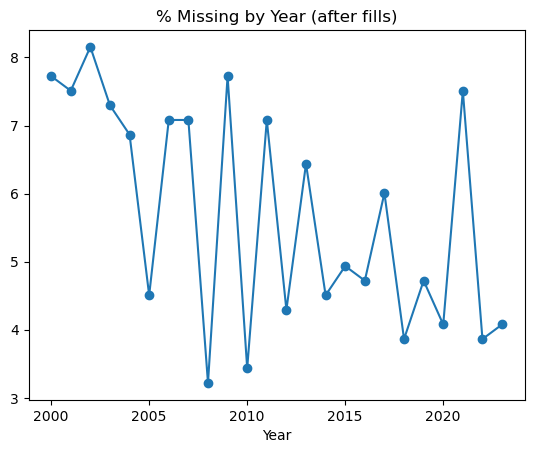

In [88]:
(df.groupby("Year")["Value"].apply(lambda x: x.isna().mean()*100)
   .plot(kind="line", marker="o", title="% Missing by Year (after fills)"))


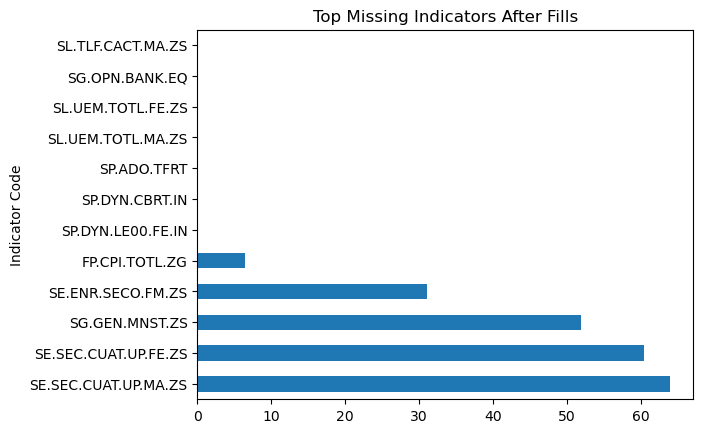

In [89]:
post = (df.groupby("Indicator Code")["Value"].apply(lambda x: x.isna().mean()*100)
          .sort_values(ascending=False).head(12))
post.plot(kind="barh", title="Top Missing Indicators After Fills"); 


In [91]:
gap_summary = (
    df.groupby(["Indicator Name", "Country"])
    .agg(
        total_points=("Value", "size"),
        nulls=("Value", lambda x: x.isna().sum()),
        first_year=("Year", "min"),
        last_year=("Year", "max")
    )
)
gap_summary["missing_rate"] = gap_summary["nulls"] / gap_summary["total_points"]
gap_summary.sort_values("missing_rate", ascending=False).head(10)


total_points  \
Indicator Name                                     Country                     
Educational attainment, at least completed uppe... Yemen, Rep.            24   
Educational attainment, at least completed uppe... Yemen, Rep.            24   
                                                   Morocco                24   
Educational attainment, at least completed uppe... Morocco                24   
Educational attainment, at least completed uppe... Algeria                24   
School enrollment, secondary (gross), gender pa... Libya                  24   
Educational attainment, at least completed uppe... Iraq                   24   
                                                   Algeria                24   
Inflation, consumer prices (annual %)              Yemen, Rep.            24   
Educational attainment, at least completed uppe... Iraq                   24   

                                                                nulls  \
Indicator Name                                     Country              
Educational attainment, at least completed uppe... Yemen, Rep.     22   
Educational attainment, at least completed uppe... Yemen, Rep.     22   
                                                   Morocco         21   
Educational attainment, at least completed uppe... Morocco         21   
Educational attainment, at least completed uppe... Algeria         20   
School enrollment, secondary (gross), gender pa... Libya           20   
Educational attainment, at least completed uppe... Iraq            20   
                                                   Algeria         20   
Inflation, consumer prices (annual %)              Yemen, Rep.     20   
Educational attainment, at least completed uppe... Iraq            19   

                                                                first_year  \
Indicator Name                                     Country                   
Educational attainment, at least completed uppe... Yemen, Rep.        2000   
Educational attainment, at least completed uppe... Yemen, Rep.        2000   
                                                   Morocco            2000   
Educational attainment, at least completed uppe... Morocco            2000   
Educational attainment, at least completed uppe... Algeria            2000   
School enrollment, secondary (gross), gender pa... Libya              2000   
Educational attainment, at least completed uppe... Iraq               2000   
                                                   Algeria            2000   
Inflation, consumer prices (annual %)              Yemen, Rep.        2000   
Educational attainment, at least completed uppe... Iraq               2000   

                                                                last_year  \
Indicator Name                                     Country                  
Educational attainment, at least completed uppe... Yemen, Rep.       2023   
Educational attainment, at least completed uppe... Yemen, Rep.       2023   
                                                   Morocco           2023   
Educational attainment, at least completed uppe... Morocco           2023   
Educational attainment, at least completed uppe... Algeria           2023   
School enrollment, secondary (gross), gender pa... Libya             2023   
Educational attainment, at least completed uppe... Iraq              2023   
                                                   Algeria           2023   
Inflation, consumer prices (annual %)              Yemen, Rep.       2023   
Educational attainment, at least completed uppe... Iraq              2023   

                                                                missing_rate  
Indicator Name                                     Country                    
Educational attainment, at least completed uppe... Yemen, Rep.      0.916667  
Educational attainment, at least completed uppe... Yemen, Rep.      0.916667  
                                                

In [93]:
df[df['Value'].isna()]["Indicator Name"].value_counts()

Indicator Name
Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)      184
Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)    174
Proportion of women in ministerial level positions (%)                                                 162
School enrollment, secondary (gross), gender parity index (GPI)                                         97
Inflation, consumer prices (annual %)                                                                   20
Name: count, dtype: int64

In [95]:
df[df["Value"].isna()]["Country"].value_counts()


Country
Yemen, Rep.         90
Iraq                70
Saudi Arabia        55
Morocco             55
Qatar               52
Algeria             52
Oman                48
Bahrain             44
Jordan              43
Kuwait              42
Libya               37
Tunisia             37
Egypt, Arab Rep.    12
Name: count, dtype: int64

In [97]:
cont = ["SE.ENR.SECO.FM.ZS", "FP.CPI.TOTL.ZG"]
int = ["SE.SEC.CUAT.UP.MA.ZS", "SE.SEC.CUAT.UP.FE.ZS"]
catg = ["SG.GEN.MNST.ZS"]

for ind in cont:
    df.loc[df["Indicator Code"] == ind, "Value"] = (
        df.loc[df["Indicator Code"] == ind]
        .groupby("Country")["Value"]
        .transform(lambda s: s.interpolate(limit_direction="both"))
    )
for ind in int:
    df.loc[df["Indicator Code"] == ind, "Value"] = (
        df.loc[df["Indicator Code"] == ind]
        .groupby("Country")["Value"]
        .transform(lambda s:s.interpolate(limit = 2, limit_direction='forward'))
    )
    
for ind in catg:
    df.loc[df["Indicator Code"] == ind, "Value"] = (
        df.loc[df["Indicator Code"] == ind]
        .groupby("Country")["Value"]
        .transform(lambda s: s.ffill().bfill())
    )

In [98]:
remaining = df["Value"].isna().sum()
pct = remaining / len(df) * 100
print(f"✅ Remaining nulls after final fills: {remaining} ({pct:.2f}%)")


✅ Remaining nulls after final fills: 237 (2.12%)


In [99]:
gap_summary = (
    df.groupby(["Indicator Name", "Country"])
    .agg(
        total_points=("Value", "size"),
        nulls=("Value", lambda x: x.isna().sum()),
        first_year=("Year", "min"),
        last_year=("Year", "max")
    )
)
gap_summary["missing_rate"] = gap_summary["nulls"] / gap_summary["total_points"]
gap_summary.sort_values("missing_rate", ascending=False).head(10)


total_points  \
Indicator Name                                     Country                     
Educational attainment, at least completed uppe... Yemen, Rep.            24   
Educational attainment, at least completed uppe... Yemen, Rep.            24   
                                                   Morocco                24   
Educational attainment, at least completed uppe... Morocco                24   
Educational attainment, at least completed uppe... Algeria                24   
Educational attainment, at least completed uppe... Algeria                24   
Educational attainment, at least completed uppe... Jordan                 24   
Educational attainment, at least completed uppe... Jordan                 24   
                                                   Iraq                   24   
Educational attainment, at least completed uppe... Iraq                   24   

                                                                nulls  \
Indicator Name                                     Country              
Educational attainment, at least completed uppe... Yemen, Rep.     20   
Educational attainment, at least completed uppe... Yemen, Rep.     20   
                                                   Morocco         15   
Educational attainment, at least completed uppe... Morocco         15   
Educational attainment, at least completed uppe... Algeria         13   
Educational attainment, at least completed uppe... Algeria         13   
Educational attainment, at least completed uppe... Jordan          12   
Educational attainment, at least completed uppe... Jordan          12   
                                                   Iraq            12   
Educational attainment, at least completed uppe... Iraq            11   

                                                                first_year  \
Indicator Name                                     Country                   
Educational attainment, at least completed uppe... Yemen, Rep.        2000   
Educational attainment, at least completed uppe... Yemen, Rep.        2000   
                                                   Morocco            2000   
Educational attainment, at least completed uppe... Morocco            2000   
Educational attainment, at least completed uppe... Algeria            2000   
Educational attainment, at least completed uppe... Algeria            2000   
Educational attainment, at least completed uppe... Jordan             2000   
Educational attainment, at least completed uppe... Jordan             2000   
                                                   Iraq               2000   
Educational attainment, at least completed uppe... Iraq               2000   

                                                                last_year  \
Indicator Name                                     Country                  
Educational attainment, at least completed uppe... Yemen, Rep.       2023   
Educational attainment, at least completed uppe... Yemen, Rep.       2023   
                                                   Morocco           2023   
Educational attainment, at least completed uppe... Morocco           2023   
Educational attainment, at least completed uppe... Algeria           2023   
Educational attainment, at least completed uppe... Algeria           2023   
Educational attainment, at least completed uppe... Jordan            2023   
Educational attainment, at least completed uppe... Jordan            2023   
                                                   Iraq              2023   
Educational attainment, at least completed uppe... Iraq              2023   

                                                                missing_rate  
Indicator Name                                     Country                    
Educational attainment, at least completed uppe... Yemen, Rep.      0.833333  
Educational attainment, at least completed uppe... Yemen, Rep.      0.833333  
                                                

In [102]:
missing_by_indicator = (
    df[df["Value"].isna()]
    .groupby("Indicator Name")["Value"]
    .count()
    .sort_values(ascending=False)
)
print(missing_by_indicator)


Indicator Name
Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)    0
Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)      0
Name: Value, dtype: int64


In [101]:
missing_by_country=(
    df[df["Value"].isna()]
    .groupby("Country")["Value"]
    .count()
    .sort_values(ascending=False)
)
print(missing_by_country)

Country
Algeria         0
Bahrain         0
Iraq            0
Jordan          0
Kuwait          0
Morocco         0
Oman            0
Qatar           0
Saudi Arabia    0
Tunisia         0
Yemen, Rep.     0
Name: Value, dtype: int64


In [100]:
missing_by_year=(
    df[df["Value"].isna()]
    .groupby("Year")["Value"]
    .count()
    .sort_values(ascending=False)
)
print(missing_by_year)

Year
2000    0
2001    0
2022    0
2021    0
2020    0
2019    0
2018    0
2017    0
2016    0
2015    0
2014    0
2013    0
2012    0
2011    0
2010    0
2009    0
2008    0
2007    0
2006    0
2005    0
2004    0
2003    0
2002    0
2023    0
Name: Value, dtype: int64


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_10648/260976140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_10648/260976140.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


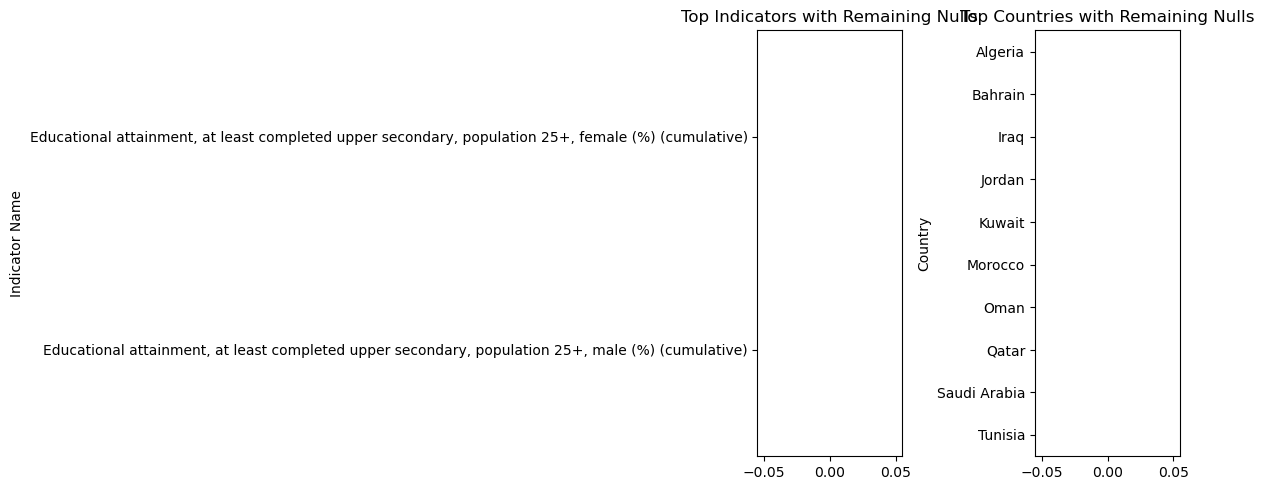

In [104]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(
    y=missing_by_indicator.head(10).index,
    x=missing_by_indicator.head(10).values,
    ax=ax[0], palette="crest"
)
ax[0].set_title("Top Indicators with Remaining Nulls")

sns.barplot(
    y=missing_by_country.head(10).index,
    x=missing_by_country.head(10).values,
    ax=ax[1], palette="mako"
)
ax[1].set_title("Top Countries with Remaining Nulls")
plt.tight_layout()
plt.show()